<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/02_youtube_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Saving PyTorch model

In [1]:
# stopped at 7:22

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() \
                      else "mps" if torch.backends.mps.is_available()\
                      else "cpu")

In [4]:
from pathlib import Path

torch.manual_seed(42)

SAVE_MODEL_DIR = Path("./models")
SAVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "model.pth"
MODEL_SAVE_PATH = SAVE_MODEL_DIR / MODEL_NAME # forward slash like unix

model = nn.Linear(1,1) # one neuron for each layer
model.to("cpu") # make sure save on CPU for OS agnostic purposes

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [5]:
model.state_dict() # weights and biases are randomly initialized

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [6]:
!ls -l ./models/ && echo && du -h ./models/

total 4
-rw-r--r-- 1 root root 1877 Jan 27 04:20 model.pth

8.0K	./models/


In [7]:
# if saved on GPU, it will try to load on GPU, but if
# other computer does not have a GPU, then it will throw an error
# make sure to make it OS agnostic by saving on CPU

In [8]:
# create an instance of the same model in order for architeture to match
# and be able to load into it
loaded_model_0 = nn.Linear(1,1)

loaded_model_0

Linear(in_features=1, out_features=1, bias=True)

In [9]:
print(MODEL_SAVE_PATH)

models/model.pth


In [10]:
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [11]:
model.state_dict()

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [12]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [13]:
model.state_dict() == loaded_model_0.state_dict()

True

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([5, 1])) that is different to the input size (torch.Size([4, 5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


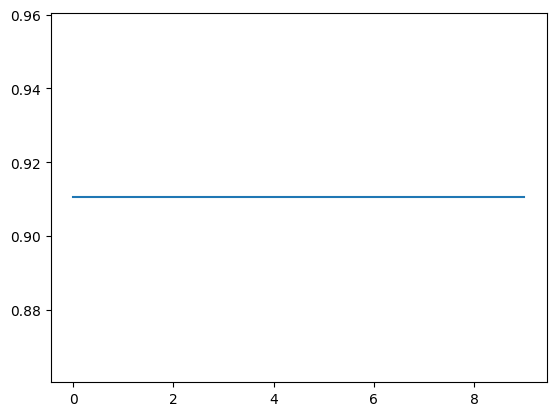

In [14]:
import matplotlib.pyplot as plt


x_test = torch.randn(4,5,1)
y_test = x_test[-1]
loaded_model_0.to(device)
loaded_model_0.eval()
test_loss = []
loss_fn = nn.L1Loss()

with torch.inference_mode():
  for i in range(10):
    output = loaded_model_0(x_test)
    loss = loss_fn(output, y_test)
    test_loss.append(loss.item())

plt.plot(test_loss)
plt.show()

In [15]:
torch.__version__

'2.9.0+cpu'

In [16]:
weight = 0.7
bias = 0.3

X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

X.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [21]:
linear_model = nn.Linear(1,1)

print(linear_model.state_dict())

OrderedDict({'weight': tensor([[0.4209]]), 'bias': tensor([0.8928])})


In [22]:
# stopped at 9:00

## NN

In [20]:
import sklearn
from sklearn.datasets import make_circles

In [25]:
n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [39]:
X.shape, y.shape # (1000=examples, 2=features)

((1000, 2), (1000,))

In [40]:
len(X), len(y)

(1000, 1000)

In [41]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [42]:
display(X[:5], y[:5])

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343]])

array([1, 1, 1, 1, 0])

In [44]:
y # binary classification

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [46]:
X # input features

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [47]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],  # first column
                        "X2": X[:, 1],  # second column
                        "label": y})    # target label

In [50]:
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['X1'].plot(kind='hist', bins=20, title='X1')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['X2'].plot(kind='hist', bins=20, title='X2')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['label'].plot(kind='hist', bins=20, title='label')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_11['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_12['X1'].plot(kind='line', figsize=(8, 4), title='X1')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['X2'].plot(kind='line', figsize=(8, 4), title='X2')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['label'].plot(kind='line', figsize=(8, 4), title='label')
plt.gca().spines[['top', 'right']].set_visible(False)

In [52]:
len(circles) # 1000 rows/examples/instances

1000

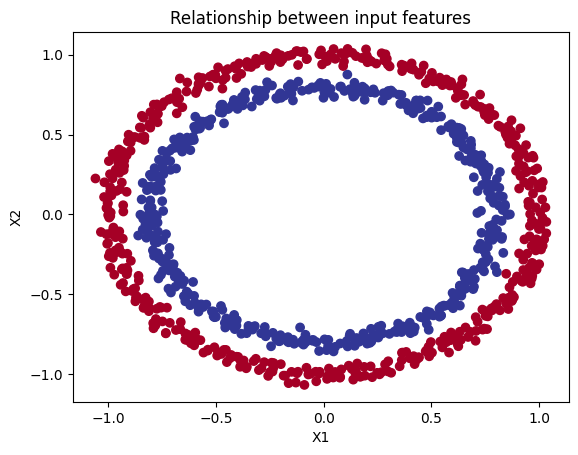

In [67]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0], # first column
            y=X[:, 1], # second column
            c=y,
            cmap=plt.cm.RdYlBu)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Relationship between input features")
plt.show()

# relationship between input features

In [65]:
circles.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


from matplotlib import pyplot as plt
_df_15['X1'].plot(kind='hist', bins=20, title='X1')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_16['X2'].plot(kind='hist', bins=20, title='X2')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_17['label'].plot(kind='hist', bins=20, title='label')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_18.groupby('index').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_24['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_24, x='X1', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_25['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_25, x='X2', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_26['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_26, x='label', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

## Check input and output shapes

In [72]:
circles["X1"].shape, circles["X2"].shape, circles["label"].shape

((1000,), (1000,), (1000,))

In [74]:
X_sample = X[0] # first row
y_sample = y[0] # first row

print(f"one sample for X={X_sample}, shape={X_sample.shape}")
print(f"one sample for y={y_sample}, shape={y_sample.shape}")

one sample for X=[0.75424625 0.23148074], shape=(2,)
one sample for y=1, shape=()


## Turn data into Tensors

In [75]:
import torch
torch.__version__

'2.9.0+cpu'

In [78]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [77]:
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [79]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [80]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [81]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

# Splitting dataset

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 80% for train
                                                    shuffle=True,
                                                    random_state=42)


In [85]:
len(X_train), len(X_test)

(800, 200)

In [88]:
len(y_train), len(y_test)

(800, 200)

In [91]:
X_train.shape, X_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]))

In [92]:
y_train.shape, y_test.shape

(torch.Size([800]), torch.Size([200]))